In [17]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn.impute import SimpleImputer

In [18]:
DATASET_PATH = Path("../data/dataset_balanceado.csv")
df = pd.read_csv(DATASET_PATH, low_memory=False)

In [19]:
print("Dimensão")
print(len(df), "linhas,", df.shape[1], "colunas")

print("\nColunas")
for nome in df.columns:
    print("-", nome)

print("\nDtypes")
print(df.dtypes)

print("\nInfo")
df.info(memory_usage=False)

print("\nNulos (NaN)")
nan_count = df.isna().sum()
nan_pct = (nan_count / len(df) * 100).round(4)
tbl_nulos = pd.DataFrame({"nan": nan_count, "pct": nan_pct})
tbl_nulos = tbl_nulos[tbl_nulos["nan"] > 0].sort_values("nan", ascending=False)
if tbl_nulos.empty:
    print("Nenhum NaN.")
else:
    print(tbl_nulos.to_string())

colunas_categoricas = [
    "id.orig_h",
    "id.resp_h",
    "proto",
    "conn_state",
    "history",
    "label",
    "detailed-label",
    "scenario",
]
cats = [c for c in colunas_categoricas if c in df.columns]

print("\nColunas categóricas")
for c in cats:
    print("-", c)

print("\nStrings vazias após strip (dataset completo)")
for col in cats:
    s = df[col].astype(str)
    n_blank = int((s.str.strip() == "").sum())
    if n_blank:
        print(col, n_blank)

print("\nSentinels Zeek \"-\" e \"(empty)\" (dataset completo)")
for col in cats:
    s = df[col].astype(str).str.strip()
    for sent in ("-", "(empty)"):
        n = int((s == sent).sum())
        if n:
            print(col, repr(sent), n)

print("\nValores distintos por coluna")
print(df.nunique(dropna=False).sort_values(ascending=False).to_string())

nums = df.select_dtypes(include=["number"]).columns.tolist()
if nums:
    print("\nDescribe numéricas")
    print(df[nums].describe().T.to_string())

if cats:
    print("\nDescribe colunas categóricas")
    print(df[cats].describe().T.to_string())


Dimensão
16457968 linhas, 24 colunas

Colunas
- ts
- uid
- id.orig_h
- id.orig_p
- id.resp_h
- id.resp_p
- proto
- service
- duration
- orig_bytes
- resp_bytes
- conn_state
- local_orig
- local_resp
- missed_bytes
- history
- orig_pkts
- orig_ip_bytes
- resp_pkts
- resp_ip_bytes
- tunnel_parents
- label
- detailed-label
- scenario

Dtypes
ts                float64
uid                   str
id.orig_h             str
id.orig_p           int64
id.resp_h             str
id.resp_p           int64
proto                 str
service               str
duration              str
orig_bytes            str
resp_bytes            str
conn_state            str
local_orig            str
local_resp            str
missed_bytes        int64
history               str
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
tunnel_parents        str
label                 str
detailed-label        str
scenario              str
dtype: object

Info
<class 'pandas.

In [20]:
print("label antes:")
print(df["label"].astype(str).str.strip().value_counts())

mask = df["label"].astype(str).str.strip().str.lower() == "benign"
df.loc[mask, "label"] = "Benign"

print("\nlabel depois:")
print(df["label"].astype(str).str.strip().value_counts())


label antes:
label
Malicious    13993698
Benign        2462444
benign           1826
Name: count, dtype: int64

label depois:
label
Malicious    13993698
Benign        2464270
Name: count, dtype: int64


        coluna  nan  vazio_strip  dash_zeek  empty_zeek    total      pct
    local_orig    0            0   16457968           0 16457968 100.0000
    local_resp    0            0   16457968           0 16457968 100.0000
       service    0            0   16426647           0 16426647  99.8097
tunnel_parents    0            0   15349379     1042863 16392242  99.6006
      duration    0            0   11693325           0 11693325  71.0496
    resp_bytes    0            0   11693325           0 11693325  71.0496
    orig_bytes    0            0   11693325           0 11693325  71.0496
detailed-label    0            0    2464270           0  2464270  14.9731
       history    0            0      32958           0    32958   0.2003
         proto    0            0          0           0        0   0.0000
     id.resp_h    0            0          0           0        0   0.0000
     id.resp_p    0            0          0           0        0   0.0000
           uid    0            0      

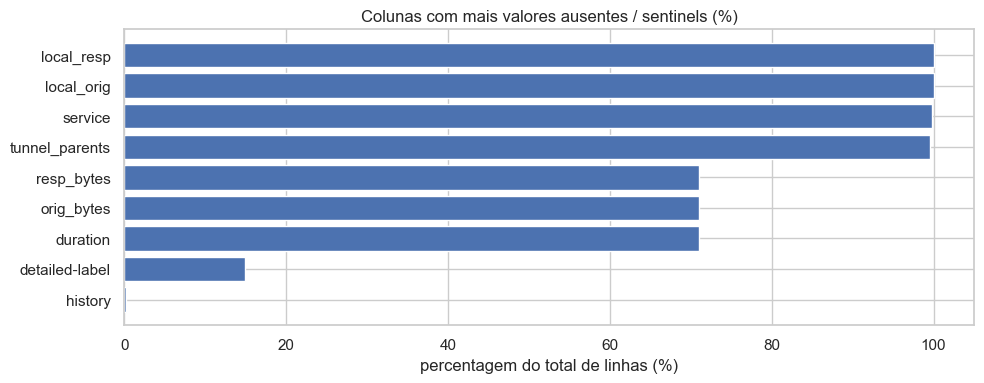

In [23]:
n = len(df)
linhas = []
for col in df.columns:
    serie = df[col]
    n_nan = int(serie.isna().sum())
    if pd.api.types.is_numeric_dtype(serie):
        n_vazio = 0
        n_dash = 0
        n_empty_paren = 0
    else:
        s = serie.astype(str).str.strip()
        n_vazio = int(s.eq("").sum())
        n_dash = int(s.eq("-").sum())
        n_empty_paren = int(s.eq("(empty)").sum())
    total = n_nan + n_vazio + n_dash + n_empty_paren
    pct = round(100 * total / n, 4) if n else 0.0
    linhas.append(
        {
            "coluna": col,
            "nan": n_nan,
            "vazio_strip": n_vazio,
            "dash_zeek": n_dash,
            "empty_zeek": n_empty_paren,
            "total": total,
            "pct": pct,
        }
    )

tbl = pd.DataFrame(linhas).sort_values("total", ascending=False)
print(tbl.to_string(index=False))

com_problema = tbl[tbl["total"] > 0]
if com_problema.empty:
    print("Sem NaN, vazios nem sentinels Zeek '-' / '(empty)'.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(com_problema))))
    ordem = com_problema.sort_values("pct", ascending=True)
    ax.barh(ordem["coluna"].astype(str), ordem["pct"])
    ax.set_xlabel("percentagem do total de linhas (%)")
    ax.set_title("Colunas com mais valores ausentes / sentinels (%)")
    plt.tight_layout()
    plt.show()


Dimensão após remover local_orig, local_resp, service, tunnel_parents
16457968 linhas, 20 colunas
Colunas: ['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'detailed-label', 'scenario']

Ausências por coluna (após remoção)
        coluna  nan  vazio_strip  dash_zeek  empty_zeek    total     pct
    orig_bytes    0            0   11693325           0 11693325 71.0496
    resp_bytes    0            0   11693325           0 11693325 71.0496
      duration    0            0   11693325           0 11693325 71.0496
detailed-label    0            0    2464270           0  2464270 14.9731
       history    0            0      32958           0    32958  0.2003
     id.orig_h    0            0          0           0        0  0.0000
           uid    0            0          0           0        0  0.0000
            ts   

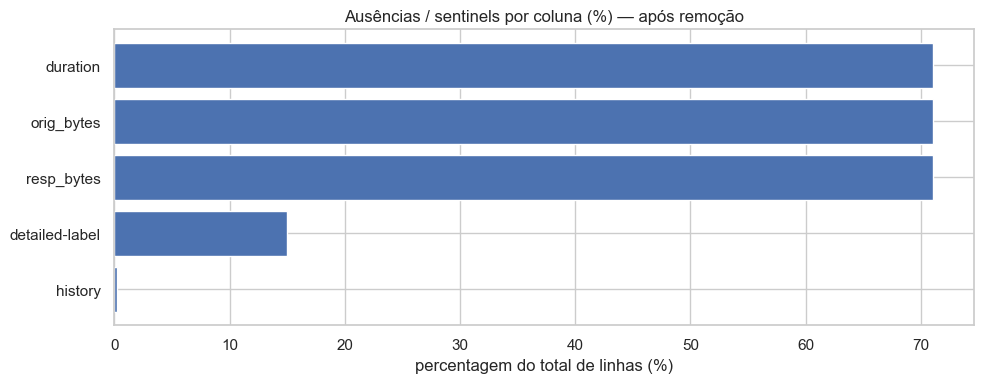

In [26]:
remover = ["local_resp", "local_orig", "service", "tunnel_parents"]
df = df.drop(columns=[c for c in remover if c in df.columns])

print("Dimensão após remover local_orig, local_resp, service, tunnel_parents")
print(len(df), "linhas,", df.shape[1], "colunas")
print("Colunas:", list(df.columns))

n = len(df)
linhas = []
for col in df.columns:
    serie = df[col]
    n_nan = int(serie.isna().sum())
    if pd.api.types.is_numeric_dtype(serie):
        n_vazio = 0
        n_dash = 0
        n_empty_paren = 0
    else:
        s = serie.astype(str).str.strip()
        n_vazio = int(s.eq("").sum())
        n_dash = int(s.eq("-").sum())
        n_empty_paren = int(s.eq("(empty)").sum())
    total = n_nan + n_vazio + n_dash + n_empty_paren
    pct = round(100 * total / n, 4) if n else 0.0
    linhas.append(
        {
            "coluna": col,
            "nan": n_nan,
            "vazio_strip": n_vazio,
            "dash_zeek": n_dash,
            "empty_zeek": n_empty_paren,
            "total": total,
            "pct": pct,
        }
    )

tbl = pd.DataFrame(linhas).sort_values("total", ascending=False)
print("\nAusências por coluna (após remoção)")
print(tbl.to_string(index=False))

com_problema = tbl[tbl["total"] > 0]
if com_problema.empty:
    print("Sem NaN, vazios nem sentinels Zeek '-' / '(empty)'.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(com_problema))))
    ordem = com_problema.sort_values("pct", ascending=True)
    ax.barh(ordem["coluna"].astype(str), ordem["pct"])
    ax.set_xlabel("percentagem do total de linhas (%)")
    ax.set_title("Ausências / sentinels por coluna (%) — após remoção")
    plt.tight_layout()
    plt.show()


In [ ]:
import ipaddress

sentinels = {"-", "(empty)", ""}


def limpar_objeto(serie):
    s = serie.astype(str).str.strip()
    return s.replace(dict.fromkeys(sentinels, np.nan)).replace("", np.nan)


for col in df.columns:
    if col == "label":
        continue
    if df[col].dtype == object or getattr(df[col].dtype, "name", "") == "string":
        df[col] = limpar_objeto(df[col])

for col in ("duration", "orig_bytes", "resp_bytes"):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


def ip_valido(x):
    if pd.isna(x):
        return False
    try:
        ipaddress.ip_address(str(x).strip())
        return True
    except (ValueError, AttributeError, TypeError):
        return False


mo = df["id.orig_h"].map(ip_valido)
mr = df["id.resp_h"].map(ip_valido)
bad = ~(mo & mr)
n_bad = int(bad.sum())
n = len(df)
if n_bad > 0:
    if n_bad / n <= 0.01:
        df = df.loc[~bad].reset_index(drop=True)
        print("linhas removidas (ip invalido):", n_bad)
    else:
        df["flag_ip_orig_invalido"] = (~mo).astype(np.int8)
        df["flag_ip_resp_invalido"] = (~mr).astype(np.int8)
        print("linhas com ip invalido (flags):", n_bad)

exc_num = {"label"}
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exc_num]
for col in num_cols:
    df[col] = df.groupby("label", dropna=False)[col].transform(lambda x: x.fillna(x.median()))
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != "label"]


def fill_modo(s):
    m = s.mode()
    if len(m):
        return s.fillna(m.iloc[0])
    return s


for col in cat_cols:
    df[col] = df.groupby("label", dropna=False)[col].transform(fill_modo)
for col in cat_cols:
    m = df[col].mode()
    df[col] = df[col].fillna(m.iloc[0] if len(m) else "missing")

print(len(df), "linhas apos tratamento")


                   ts  id.orig_p  id.resp_p  missed_bytes  orig_pkts  orig_ip_bytes  resp_pkts  resp_ip_bytes  duration  orig_bytes  resp_bytes
ts             1.0000     0.5269    -0.1488        0.0000     0.0014         0.0006    -0.0006        -0.0003    0.0276      0.0204      0.0001
id.orig_p      0.5269     1.0000    -0.3960        0.0001     0.0001         0.0001     0.0003         0.0002    0.0047      0.0018      0.0004
id.resp_p     -0.1488    -0.3960     1.0000       -0.0002    -0.0000        -0.0002    -0.0005        -0.0002    0.0085     -0.0354     -0.0004
missed_bytes   0.0000     0.0001    -0.0002        1.0000     0.0000         0.0000     0.0000         0.0000    0.0010     -0.0000      0.4747
orig_pkts      0.0014     0.0001    -0.0000        0.0000     1.0000         0.3400     0.0083         0.0081    0.0093      0.0004      0.0031
orig_ip_bytes  0.0006     0.0001    -0.0002        0.0000     0.3400         1.0000     0.0037         0.0035    0.0048      0.0007     

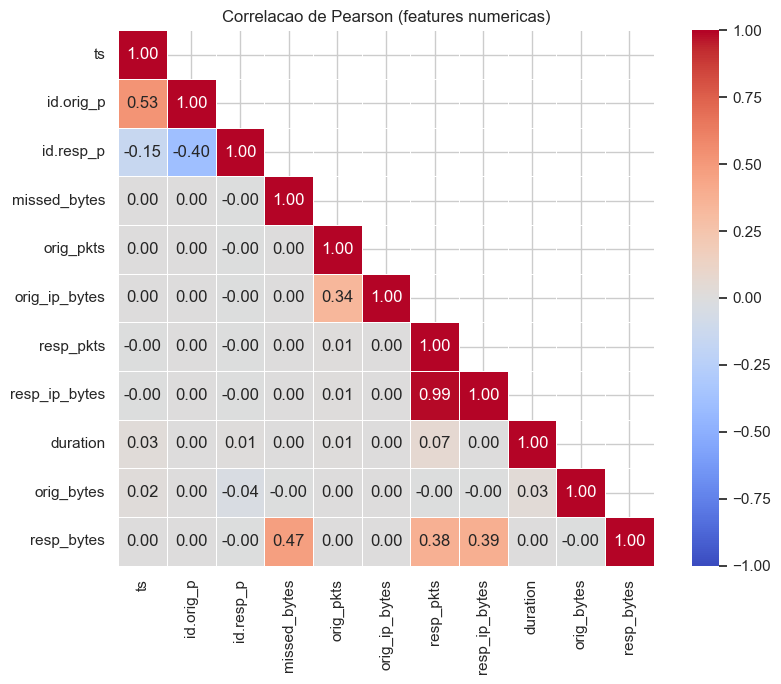

            a             b         r      |r|
resp_ip_bytes     resp_pkts  0.991981 0.991981
    id.orig_p            ts  0.526873 0.526873
   resp_bytes  missed_bytes  0.474666 0.474666
    id.resp_p     id.orig_p -0.395971 0.395971
   resp_bytes resp_ip_bytes  0.385791 0.385791
   resp_bytes     resp_pkts  0.382503 0.382503
orig_ip_bytes     orig_pkts  0.339971 0.339971
    id.resp_p            ts -0.148813 0.148813
     duration     resp_pkts  0.068350 0.068350
   orig_bytes     id.resp_p -0.035400 0.035400
   orig_bytes      duration  0.034101 0.034101
     duration            ts  0.027583 0.027583
   orig_bytes            ts  0.020412 0.020412
     duration     orig_pkts  0.009321 0.009321
     duration     id.resp_p  0.008478 0.008478
    resp_pkts     orig_pkts  0.008278 0.008278
resp_ip_bytes     orig_pkts  0.008089 0.008089
     duration orig_ip_bytes  0.004753 0.004753
     duration     id.orig_p  0.004667 0.004667
     duration resp_ip_bytes  0.003698 0.003698
    resp_pkts

In [27]:
cols_coerce = ["duration", "orig_bytes", "resp_bytes"]
partes = [df.select_dtypes(include=["number"]).copy()]
for c in cols_coerce:
    if c not in df.columns:
        continue
    s = df[c].astype(str).str.strip()
    s = s.replace({"-": np.nan, "(empty)": np.nan, "": np.nan})
    partes.append(pd.to_numeric(s, errors="coerce").rename(c))
num = pd.concat(partes, axis=1)
num = num.loc[:, ~num.columns.duplicated()]
num = num.dropna(axis=1, how="all")

corr = num.corr(method="pearson", min_periods=3)
print(corr.round(4).to_string())

n = len(corr.columns)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
plt.figure(figsize=(max(9, 0.55 * n), max(7, 0.45 * n)))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    mask=mask,
    linewidths=0.5,
)
plt.title("Correlacao de Pearson (features numericas)")
plt.tight_layout()
plt.show()

cols_list = list(corr.columns)
pairs = []
for i in range(n):
    for j in range(i):
        r = corr.iloc[i, j]
        if pd.notna(r):
            pairs.append((cols_list[i], cols_list[j], r, abs(r)))
pairs.sort(key=lambda x: -x[3])
print(pd.DataFrame(pairs[:25], columns=["a", "b", "r", "|r|"]).to_string(index=False))


In [28]:
import ipaddress


def ip_e_privado(x):
    try:
        return ipaddress.ip_address(str(x).strip()).is_private
    except ValueError:
        return np.nan


tb = df["orig_pkts"].astype(np.float64) + df["resp_pkts"].astype(np.float64)
bb = df["orig_ip_bytes"].astype(np.float64) + df["resp_ip_bytes"].astype(np.float64)
df["tam_medio_pacote"] = np.where(tb > 0, bb / tb, np.nan)

priv_orig = df["id.orig_h"].map(ip_e_privado)
priv_resp = df["id.resp_h"].map(ip_e_privado)
valid = priv_orig.notna() & priv_resp.notna()
po = priv_orig[valid].to_numpy(dtype=bool)
pr = priv_resp[valid].to_numpy(dtype=bool)
codes = np.full(len(df), np.nan)
codes[valid.to_numpy()] = (po.astype(np.int8) << 1) | pr.astype(np.int8)
df["escopo_ips"] = codes

legenda = {
    0: "ambos_publicos",
    1: "orig_public_resp_privado",
    2: "orig_priv_resp_public",
    3: "ambos_privados",
}
print("escopo_ips:", legenda)
print(df["escopo_ips"].value_counts(dropna=False).sort_index().to_string())
print("tam_medio_pacote describe:")
print(df["tam_medio_pacote"].describe().to_string())


escopo_ips: {0: 'ambos_publicos', 1: 'orig_public_resp_privado', 2: 'orig_priv_resp_public', 3: 'ambos_privados'}
escopo_ips
0.0       60915
1.0       46098
2.0    16312449
3.0       38506
tam_medio_pacote describe:
count    1.626526e+07
mean     4.438427e+01
std      4.055039e+01
min      2.800000e+01
25%      4.000000e+01
50%      4.000000e+01
75%      4.000000e+01
max      6.327095e+03


In [29]:
import ipaddress

label_col = "label"
limite_pct_ips = 1.0

print(len(df), "linhas (antes)")


def ip_valid(x):
    if pd.isna(x):
        return False
    try:
        ipaddress.ip_address(str(x).strip())
        return True
    except ValueError:
        return False


def ip_e_privado(x):
    try:
        return ipaddress.ip_address(str(x).strip()).is_private
    except ValueError:
        return np.nan


for c in df.columns:
    if df[c].dtype != object and not pd.api.types.is_string_dtype(df[c]):
        continue
    s = df[c].astype(str).str.strip()
    s = s.mask(s.str.lower().eq("nan"), np.nan)
    s = s.replace({"-": np.nan, "(empty)": np.nan, "": np.nan})
    df[c] = s

for c in ["duration", "orig_bytes", "resp_bytes"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

vo = df["id.orig_h"].map(ip_valid)
vr = df["id.resp_h"].map(ip_valid)
invalid = ~(vo & vr)
n_inv = int(invalid.sum())
pct = 100.0 * n_inv / len(df) if len(df) else 0.0
print("IPs invalidos:", n_inv, f"({pct:.4f}%)")

if n_inv > 0:
    if pct <= limite_pct_ips:
        df = df.loc[~invalid].copy()
        print("Linhas removidas:", n_inv)
    else:
        df.loc[invalid, "id.orig_h"] = np.nan
        df.loc[invalid, "id.resp_h"] = np.nan
        print("IPs invalidos marcados como NaN.")

obj_cols2 = df.select_dtypes(include=["object"]).columns.tolist()
for col in obj_cols2:
    if not df[col].isna().any():
        continue
    if col in ("id.orig_h", "id.resp_h"):
        df[col] = df[col].fillna("missing")
        continue
    m = df[col].mode()
    if len(m):
        df[col] = df[col].fillna(m.iloc[0])
    df[col] = df[col].fillna("missing")

tb = df["orig_pkts"].astype(np.float64) + df["resp_pkts"].astype(np.float64)
bb = df["orig_ip_bytes"].astype(np.float64) + df["resp_ip_bytes"].astype(np.float64)
df["tam_medio_pacote"] = np.where(tb > 0, bb / tb, np.nan)

priv_orig = df["id.orig_h"].map(ip_e_privado)
priv_resp = df["id.resp_h"].map(ip_e_privado)
valid = priv_orig.notna() & priv_resp.notna()
po = priv_orig[valid].to_numpy(dtype=bool)
pr = priv_resp[valid].to_numpy(dtype=bool)
codes = np.full(len(df), np.nan)
codes[valid.to_numpy()] = (po.astype(np.int8) << 1) | pr.astype(np.int8)
df["escopo_ips"] = codes

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if not df[col].isna().any():
        continue
    med_cls = df.groupby(label_col, dropna=False)[col].transform("median")
    df[col] = df[col].fillna(med_cls)
    df[col] = df[col].fillna(df[col].median())

print(len(df), "linhas (depois)")
print("total NaN:", int(df.isna().sum().sum()))


16457968 linhas (antes)
IPs invalidos: 0 (0.0000%)
16457968 linhas (depois)
total NaN: 0


In [31]:
from sklearn.preprocessing import RobustScaler

label_col = "label"
nao_escalar = {"escopo_ips"}

cols_escalar = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c != label_col and c not in nao_escalar
]

print(f'Colunas que nao serao escaladas: {cols_escalar}')

scaler_rt = RobustScaler()
df[cols_escalar] = scaler_rt.fit_transform(df[cols_escalar].astype(np.float64))

print("RobustScaler aplicado a:", cols_escalar)


Colunas que nao serao escaladas: ['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote']
RobustScaler aplicado a: ['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote']


In [32]:
label_col = "label"
nao_escalar = {"escopo_ips"}
cols_escalar = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c != label_col and c not in nao_escalar
]

print("Dimensao:", len(df), "linhas,", df.shape[1], "colunas")
print("\nDtypes")
print(df.dtypes.to_string())

print("\nColunas com RobustScaler:")
print(cols_escalar)

print("\ndescribe() — colunas escaladas")
print(df[cols_escalar].describe().T.to_string())

extras = [c for c in ("escopo_ips", "label") if c in df.columns]
print("\nPrimeiras 10 linhas (escaladas +", extras, ")")
print(df[cols_escalar + extras].head(10).to_string())

print("\nNaN por coluna (escaladas)")
print(df[cols_escalar].isna().sum().to_string())


Dimensao: 16457968 linhas, 22 colunas

Dtypes
ts                  float64
uid                     str
id.orig_h               str
id.orig_p           float64
id.resp_h               str
id.resp_p           float64
proto                   str
duration            float64
orig_bytes          float64
resp_bytes          float64
conn_state              str
missed_bytes        float64
history                 str
orig_pkts           float64
orig_ip_bytes       float64
resp_pkts           float64
resp_ip_bytes       float64
label                   str
detailed-label          str
scenario                str
tam_medio_pacote    float64
escopo_ips          float64

Colunas com RobustScaler:
['ts', 'id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tam_medio_pacote']

describe() — colunas escaladas
                       count          mean           std        min       25%           50%       75%         